# 10 Interpretacja modelu dla `drop_10`

Ten notebook interpretuje model wybrany w etapie 09: `behavior_random_forest` trenowany na zestawie `behavior_primary` dla targetu `drop_10`.

Celem jest odpowiedź na pytanie, które sygnały telemetryczne są najważniejsze dla predykcji przyszłego spadku BWCI oraz czy predykcje modelu układają się w spójny ranking ryzyka. Interpretacja dotyczy modelu behawioralnego, nie psychologicznego pomiaru skupienia.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.pipeline import Pipeline

PROJECT_ROOT_CANDIDATES: list[Path] = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next((path for path in PROJECT_ROOT_CANDIDATES if (path / "AGENTS.md").exists()), Path.cwd())
OUTPUT_DIR = PROJECT_ROOT / "outputs"
DATASET_PATH = OUTPUT_DIR / "model_dataset_drop_10_v0_1.parquet"
METADATA_PATH = OUTPUT_DIR / "model_dataset_drop_10_v0_1_metadata.json"
MODEL_DECISION_PATH = OUTPUT_DIR / "final_model_decision_drop_10_v0_1.json"
LOGO_RESULTS_PATH = OUTPUT_DIR / "final_logo_results_drop_10_v0_1.csv"

FEATURE_IMPORTANCE_PATH = OUTPUT_DIR / "model_interpretation_feature_importance_drop_10_v0_1.csv"
PERMUTATION_IMPORTANCE_PATH = OUTPUT_DIR / "model_interpretation_permutation_drop_10_v0_1.csv"
RISK_DECILES_PATH = OUTPUT_DIR / "model_interpretation_risk_deciles_drop_10_v0_1.csv"
FEATURE_PROFILES_PATH = OUTPUT_DIR / "model_interpretation_feature_profiles_drop_10_v0_1.csv"
SUMMARY_PATH = OUTPUT_DIR / "model_interpretation_summary_drop_10_v0_1.json"

TARGET_COL = "drop_10"
RANDOM_STATE = 42
THRESHOLD = 0.50
N_REPEATS = 3

sns.set_theme(style="whitegrid", palette="muted", font_scale=0.9)
pd.set_option("display.max_rows", 140)
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")


## Sekcja 1: Dane, model i odtworzenie wyniku

Wczytujemy czysty dataset z etapu 09 i trenujemy ponownie wybrany model na części treningowej temporal split. To pozwala zinterpretować dokładnie ten sam wariant modelu, który został wybrany do dalszej analizy.


In [2]:
if not DATASET_PATH.exists():
  raise FileNotFoundError(f"Missing clean dataset: {DATASET_PATH}")
if not METADATA_PATH.exists():
  raise FileNotFoundError(f"Missing clean metadata: {METADATA_PATH}")
if not MODEL_DECISION_PATH.exists():
  raise FileNotFoundError(f"Missing model decision: {MODEL_DECISION_PATH}")

model_dataset = pd.read_parquet(DATASET_PATH)
metadata = json.loads(METADATA_PATH.read_text())
model_decision = json.loads(MODEL_DECISION_PATH.read_text())
features: list[str] = metadata["feature_sets"]["behavior_primary"]

train_df = model_dataset[model_dataset["temporal_split"] == "train"].copy()
test_df = model_dataset[model_dataset["temporal_split"] == "test"].copy()

selected_model = Pipeline(
  steps=[
    ("imputer", SimpleImputer(strategy="median")),
    (
      "model",
      RandomForestClassifier(
        n_estimators=120,
        min_samples_leaf=50,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
      ),
    ),
  ]
)
selected_model.fit(train_df[features], train_df[TARGET_COL].astype(int))

y_test = test_df[TARGET_COL].astype(int)
y_proba = selected_model.predict_proba(test_df[features])[:, 1]
y_pred = (y_proba >= THRESHOLD).astype(int)

model_recheck = pd.DataFrame(
  [
    {
      "model": model_decision["selected_model"],
      "feature_set": model_decision["selected_feature_set"],
      "rows_test": len(test_df),
      "positive_pct_test": y_test.mean() * 100,
      "auc_pr": average_precision_score(y_test, y_proba),
      "roc_auc": roc_auc_score(y_test, y_proba),
      "brier": brier_score_loss(y_test, y_proba),
      "predicted_positive_pct": y_pred.mean() * 100,
      "recall_pos": ((y_test == 1) & (y_pred == 1)).sum() / y_test.sum(),
    }
  ]
)
model_recheck


,model,feature_set,rows_test,positive_pct_test,auc_pr,roc_auc,brier,predicted_positive_pct,recall_pos
0,behavior_random_forest,behavior_primary,15212,15.9348,0.4111,0.8235,0.1616,30.6403,0.7248


### Interpretacja odtworzenia modelu

Odtworzony model daje na temporal test AUC-PR 0.4111, ROC-AUC 0.8235 i Brier score 0.1616. To zgadza się z decyzją z notebooka 09, więc interpretujemy właściwy wariant modelu.

Przy progu 0.50 model oznacza jako ryzykowne 30.64% obserwacji testowych i wykrywa 72.48% rzeczywistych epizodów `drop_10`. To wskazuje na model raczej czuły niż konserwatywny: dobry do rankingu i wczesnego ostrzegania, ale nie jako bardzo precyzyjny klasyfikator progowy bez dalszej kalibracji.


## Sekcja 2: Ważność cech

Porównujemy dwa źródła interpretacji: wbudowaną ważność Random Forest oraz permutation importance mierzoną spadkiem AUC-PR na teście. Permutation importance jest ważniejsza interpretacyjnie, bo sprawdza wpływ cechy na metrykę predykcyjną.


In [3]:
rf_model = selected_model.named_steps["model"]
mdi_importance = (
  pd.DataFrame({"feature": features, "mdi_importance": rf_model.feature_importances_})
  .sort_values("mdi_importance", ascending=False)
  .reset_index(drop=True)
)

permutation_result = permutation_importance(
  selected_model,
  test_df[features],
  y_test,
  scoring="average_precision",
  n_repeats=N_REPEATS,
  random_state=RANDOM_STATE,
  n_jobs=-1,
)
permutation_importance_df = (
  pd.DataFrame(
    {
      "feature": features,
      "permutation_auc_pr_drop_mean": permutation_result.importances_mean,
      "permutation_auc_pr_drop_std": permutation_result.importances_std,
    }
  )
  .sort_values("permutation_auc_pr_drop_mean", ascending=False)
  .reset_index(drop=True)
)

importance_comparison = mdi_importance.merge(permutation_importance_df, on="feature", how="outer")
display(mdi_importance.head(12))
display(permutation_importance_df.head(12))


,feature,mdi_importance
0,typing_cv,0.1462
1,idle_ratio,0.1136
2,input_sum,0.1079
3,mouse_sum,0.0989
4,erase_ratio,0.0898
5,active_apps_mean,0.0698
6,erase_sum,0.0517
7,keystroke_sum,0.0446
8,press_press_mean,0.0371
9,press_press_std,0.0365


,feature,permutation_auc_pr_drop_mean,permutation_auc_pr_drop_std
0,active_apps_mean,0.0558,0.0023
1,typing_cv,0.0552,0.0047
2,idle_ratio,0.0379,0.0056
3,input_sum,0.0254,0.0027
4,erase_ratio,0.0228,0.0009
5,mouse_sum,0.0175,0.0027
6,keystroke_sum,0.0167,0.0010
7,foreground_time_mean,0.0091,0.0029
8,erase_sum,0.0060,0.0025
9,press_press_mean,0.0052,0.0012


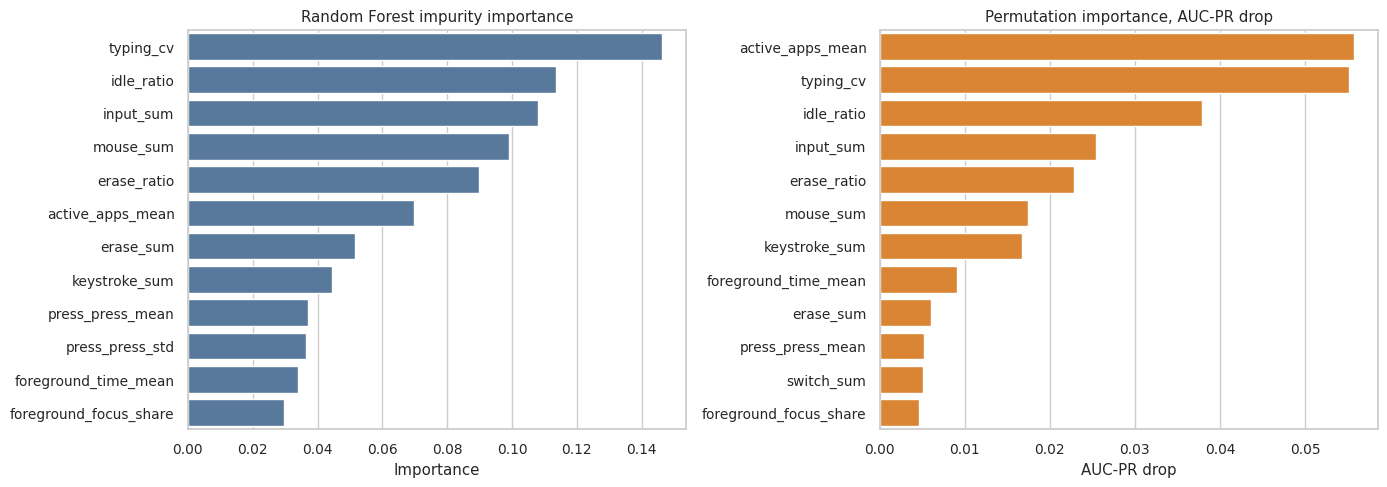

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=mdi_importance.head(12), x="mdi_importance", y="feature", ax=axes[0], color="#4C78A8")
axes[0].set_title("Random Forest impurity importance")
axes[0].set_xlabel("Importance")
axes[0].set_ylabel("")

sns.barplot(
  data=permutation_importance_df.head(12),
  x="permutation_auc_pr_drop_mean",
  y="feature",
  ax=axes[1],
  color="#F58518",
)
axes[1].set_title("Permutation importance, AUC-PR drop")
axes[1].set_xlabel("AUC-PR drop")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()


### Interpretacja ważności cech

Wbudowana ważność Random Forest wskazuje przede wszystkim `typing_cv` 0.1463, `idle_ratio` 0.1136, `input_sum` 0.1079, `mouse_sum` 0.0989 oraz `erase_ratio` 0.0898. To są cechy opisujące rytm interakcji, przerwy, intensywność wejścia oraz korekty.

Permutation importance przesuwa akcent na cechy, które realnie obniżają AUC-PR po zaburzeniu na teście: `active_apps_mean` obniża AUC-PR o 0.0558, `typing_cv` o 0.0552, `idle_ratio` o 0.0379, `input_sum` o 0.0254, a `erase_ratio` o 0.0228. Najbardziej stabilny wniosek jest więc taki, że model korzysta z trzech rodzin sygnałów: kontekstu aplikacji, regularności rytmu oraz intensywności lub braku interakcji.

To jest zgodne z koncepcją BWCI jako proxy ciągłości pracy. Model nie opiera się na jednej cesze, tylko łączy zmianę kontekstu, rytm pracy i aktywność wejściową.


## Sekcja 3: Ranking ryzyka

Sprawdzamy, czy prawdopodobieństwa modelu tworzą sensowny ranking. Dzielimy obserwacje testowe na decyle według przewidywanego ryzyka i porównujemy średnie ryzyko z rzeczywistym udziałem `drop_10`.


In [5]:
risk_df = test_df[["USER", "datetime", TARGET_COL]].copy()
risk_df["y_proba"] = y_proba
risk_df["risk_decile"] = pd.qcut(
  risk_df["y_proba"].rank(method="first"),
  10,
  labels=[str(value) for value in range(1, 11)],
).astype(int)

risk_deciles = (
  risk_df
  .groupby("risk_decile")
  .agg(
    rows=(TARGET_COL, "size"),
    positive_rows=(TARGET_COL, "sum"),
    positive_pct=(TARGET_COL, lambda values: values.mean() * 100),
    mean_predicted_risk=("y_proba", lambda values: values.mean() * 100),
    min_predicted_risk=("y_proba", lambda values: values.min() * 100),
    max_predicted_risk=("y_proba", lambda values: values.max() * 100),
  )
  .reset_index()
)

top_decile = risk_df[risk_df["risk_decile"] == 10]
top_decile_capture_pct = top_decile[TARGET_COL].sum() / risk_df[TARGET_COL].sum() * 100
risk_deciles


,risk_decile,rows,positive_rows,positive_pct,mean_predicted_risk,min_predicted_risk,max_predicted_risk
0,1,1522,0,0.0000,0.9619,0.0216,4.5837
1,2,1521,14,0.9204,7.8905,4.5882,10.6072
2,3,1521,31,2.0381,13.6014,10.6072,16.8791
3,4,1521,85,5.5884,20.5859,16.8792,24.4450
4,5,1521,116,7.6266,28.5182,24.4466,32.5566
5,6,1521,186,12.2288,36.8504,32.5577,41.0762
6,7,1521,265,17.4227,45.6143,41.0899,50.6526
7,8,1521,430,28.2709,56.4515,50.6553,62.0834
8,9,1521,569,37.4096,68.6032,62.0864,76.6761
9,10,1522,728,47.8318,83.5943,76.6761,93.6102


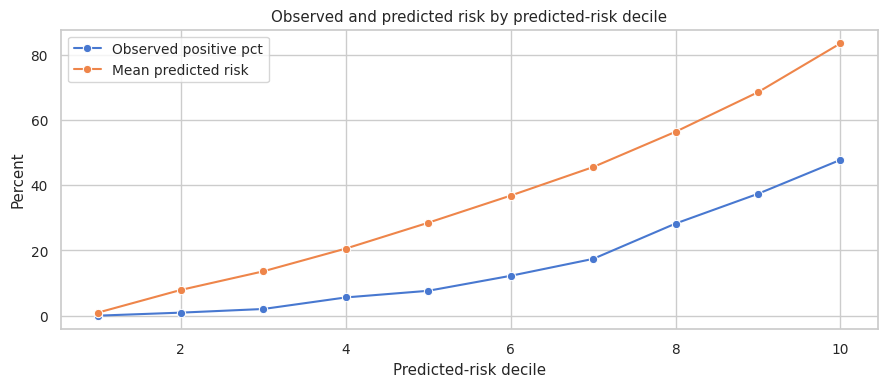

Top decile captures 30.03% of all positive events in the temporal test set.


In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.lineplot(data=risk_deciles, x="risk_decile", y="positive_pct", marker="o", label="Observed positive pct", ax=ax)
sns.lineplot(data=risk_deciles, x="risk_decile", y="mean_predicted_risk", marker="o", label="Mean predicted risk", ax=ax)
ax.set_title("Observed and predicted risk by predicted-risk decile")
ax.set_xlabel("Predicted-risk decile")
ax.set_ylabel("Percent")
plt.tight_layout()
plt.show()

print(f"Top decile captures {top_decile_capture_pct:.2f}% of all positive events in the temporal test set.")


### Interpretacja rankingu ryzyka

Ranking jest spójny: w najniższym decylu ryzyka nie ma żadnego zdarzenia `drop_10`, a w najwyższym decylu udział zdarzeń wynosi 47.83%. Dla porównania cały test ma 15.93% zdarzeń pozytywnych.

Najwyższy decyl zawiera 30.03% wszystkich pozytywnych zdarzeń z testu. To dobry argument, że model jest użyteczny jako ranking ryzyka, nawet jeśli próg 0.50 wymagałby osobnej kalibracji pod konkretny koszt false positive i false negative.


## Sekcja 4: Profile najważniejszych cech

Dla najważniejszych cech z permutation importance sprawdzamy, jak zmienia się rzeczywisty i przewidywany udział `drop_10` w kolejnych kwintylach wartości cechy. Wartości brakujące są w tym podglądzie zastąpione medianą treningową, tak jak w pipeline modelu.


In [7]:
def build_feature_profiles(
  df: pd.DataFrame,
  feature_names: list[str],
  probabilities: np.ndarray,
  target_col: str,
  bins: int = 5,
) -> pd.DataFrame:
  """ Build binned observed and predicted risk profiles for selected features.

    Args:
      df: Test dataset.
      feature_names: Feature names to profile.
      probabilities: Predicted positive probabilities aligned with df.
      target_col: Binary target column.
      bins: Number of quantile bins.

    Returns:
      pd.DataFrame: Feature profile table.
  """
  medians = train_df[feature_names].median(numeric_only=True)
  rows: list[pd.DataFrame] = []
  for feature in feature_names:
    profile_df = df[[feature, target_col]].copy()
    profile_df[feature] = profile_df[feature].fillna(medians[feature])
    profile_df["y_proba"] = probabilities
    profile_df["feature_bin"] = pd.qcut(
      profile_df[feature].rank(method="first"),
      bins,
      labels=[str(value) for value in range(1, bins + 1)],
    ).astype(int)
    summary = (
      profile_df
      .groupby("feature_bin")
      .agg(
        rows=(target_col, "size"),
        feature_mean=(feature, "mean"),
        feature_min=(feature, "min"),
        feature_max=(feature, "max"),
        positive_pct=(target_col, lambda values: values.mean() * 100),
        mean_predicted_risk=("y_proba", lambda values: values.mean() * 100),
      )
      .reset_index()
    )
    summary["feature"] = feature
    rows.append(summary)
  return pd.concat(rows, ignore_index=True)


top_profile_features = permutation_importance_df.head(5)["feature"].tolist()
feature_profiles = build_feature_profiles(test_df, top_profile_features, y_proba, TARGET_COL)
feature_profiles


,feature_bin,rows,feature_mean,feature_min,feature_max,positive_pct,mean_predicted_risk,feature
0,1,3043,3.0519,1.0000,4.0000,13.0792,35.3610,active_apps_mean
1,2,3042,4.5823,4.0000,5.2600,16.2064,34.9536,active_apps_mean
2,3,3042,6.0040,5.2610,6.9200,15.5819,34.1715,active_apps_mean
3,4,3042,8.4960,6.9200,11.5330,16.3379,35.6951,active_apps_mean
4,5,3043,36.9162,11.5400,191.3880,18.4686,41.1574,active_apps_mean
5,1,3043,0.5335,0.0000,1.1309,26.8814,54.9939,typing_cv
6,2,3042,1.5554,1.1309,1.8098,20.5128,43.3401,typing_cv
7,3,3042,1.8098,1.8098,1.8098,16.7653,35.5380,typing_cv
8,4,3042,2.0443,1.8098,2.3792,9.9277,27.6788,typing_cv
9,5,3043,3.0124,2.3794,6.8361,5.5866,19.7883,typing_cv


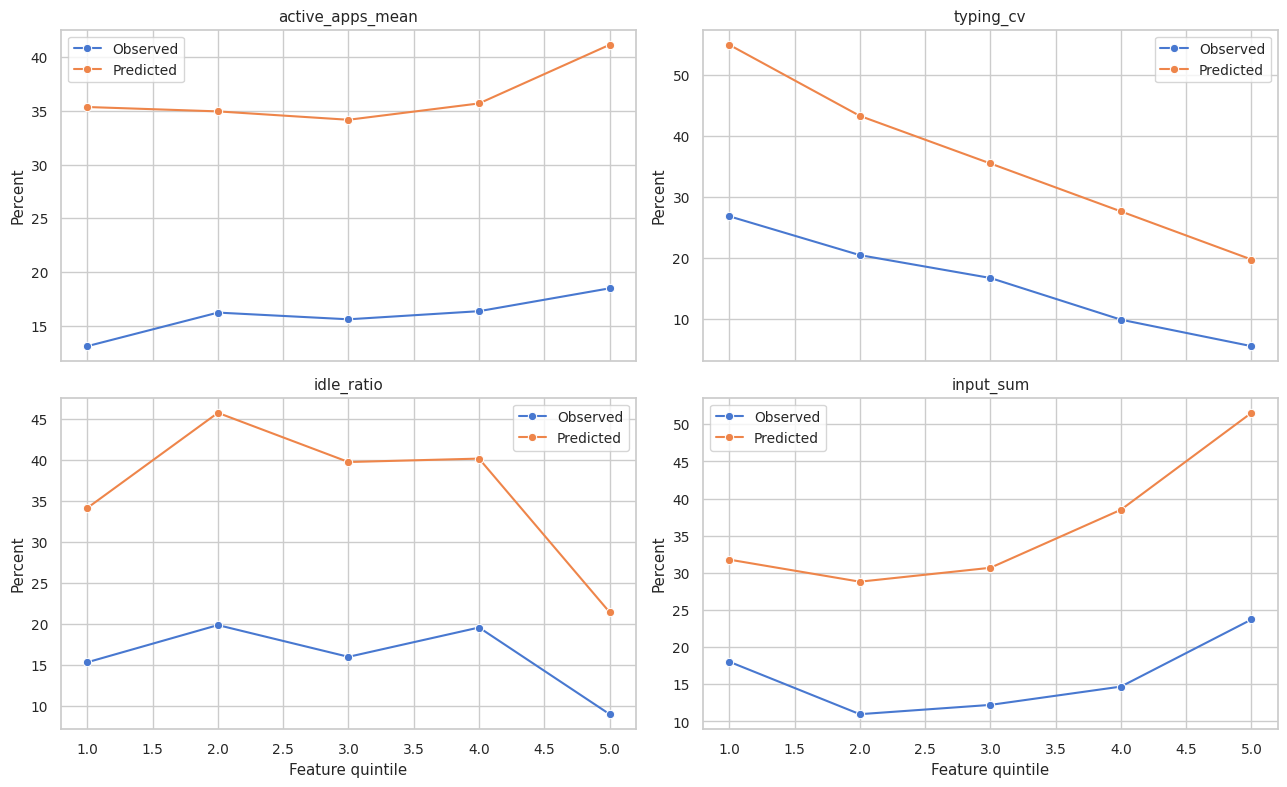

In [8]:
plot_profiles = feature_profiles[feature_profiles["feature"].isin(top_profile_features[:4])]
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for ax, feature in zip(axes.ravel(), top_profile_features[:4]):
  part = plot_profiles[plot_profiles["feature"] == feature]
  sns.lineplot(data=part, x="feature_bin", y="positive_pct", marker="o", label="Observed", ax=ax)
  sns.lineplot(data=part, x="feature_bin", y="mean_predicted_risk", marker="o", label="Predicted", ax=ax)
  ax.set_title(feature)
  ax.set_xlabel("Feature quintile")
  ax.set_ylabel("Percent")
plt.tight_layout()
plt.show()


### Interpretacja profili cech

`active_apps_mean` ma umiarkowany dodatni profil ryzyka: w najwyższym kwintylu obserwowany udział `drop_10` rośnie do 18.47%, a modelowy średni risk do 41.16%. To sugeruje, że duża liczba aktywnych aplikacji jest dla modelu sygnałem mniej stabilnego kontekstu pracy.

`typing_cv` działa odwrotnie niż intuicyjne proste założenie o nieregularności: najniższy kwintyl ma 26.20% zdarzeń, a wyższe wartości mają niższy udział zdarzeń. To oznacza, że model może traktować bardzo niski współczynnik zmienności jako epizod intensywnej, jednorodnej aktywności poprzedzającej spadek BWCI, a nie po prostu jako stabilność pracy.

`idle_ratio` nie jest liniowym sygnałem. Najwyższy kwintyl idle ma tylko 8.97% zdarzeń, podczas gdy środkowe poziomy mają wyższy udział `drop_10`. To wzmacnia decyzję, żeby nie budować targetu ani modelu na pojedynczym progu idle.

`input_sum` ma czytelniejszy kierunek: najwyższy kwintyl ma 23.73% zdarzeń i średnie przewidywane ryzyko 51.55%. Model interpretuje bardzo intensywną aktywność wejściową jako potencjalny poprzednik spadku ciągłości pracy.


## Sekcja 5: Stabilność per użytkownik

Na końcu sprawdzamy, jak model zachowuje się dla poszczególnych użytkowników w temporal test oraz jak ten obraz różni się od LOGO. To oddziela pytanie o predykcję przyszłości znanych użytkowników od pytania o generalizację na użytkownika niewidzianego w treningu.


In [9]:
def score_user_predictions(user_df: pd.DataFrame) -> pd.Series:
  """ Score model predictions for one user.

    Args:
      user_df: User-level prediction dataframe.

    Returns:
      pd.Series: User-level metric row.
  """
  y_true = user_df[TARGET_COL].astype(int)
  proba = user_df["y_proba"].to_numpy()
  pred = (proba >= THRESHOLD).astype(int)
  return pd.Series(
    {
      "rows": len(user_df),
      "positive_pct": y_true.mean() * 100,
      "auc_pr": average_precision_score(y_true, proba) if y_true.nunique() == 2 else np.nan,
      "roc_auc": roc_auc_score(y_true, proba) if y_true.nunique() == 2 else np.nan,
      "predicted_positive_pct": pred.mean() * 100,
      "recall_pos": ((y_true == 1) & (pred == 1)).sum() / y_true.sum() if y_true.sum() > 0 else np.nan,
    }
  )


temporal_user_predictions = test_df[["USER", TARGET_COL]].copy()
temporal_user_predictions["y_proba"] = y_proba
temporal_user_results = (
  temporal_user_predictions
  .groupby("USER")
  .apply(score_user_predictions, include_groups=False)
  .reset_index()
  .sort_values("auc_pr")
)

if LOGO_RESULTS_PATH.exists():
  logo_results = pd.read_csv(LOGO_RESULTS_PATH)
  logo_selected = logo_results[logo_results["model"] == model_decision["selected_model"]].copy()
else:
  logo_selected = pd.DataFrame()

display(temporal_user_results)
display(logo_selected.sort_values("auc_pr") if not logo_selected.empty else logo_selected)


,USER,rows,positive_pct,auc_pr,roc_auc,predicted_positive_pct,recall_pos
7,8,856.0000,10.8645,0.3189,0.7922,3.7383,0.1613
5,6,197.0000,11.1675,0.3511,0.8532,29.4416,0.8636
4,5,345.0000,22.0290,0.3586,0.7517,61.7391,1.0000
8,9,1149.0000,11.2272,0.3658,0.8041,13.7511,0.4961
3,4,1622.0000,11.7756,0.3966,0.8065,6.9051,0.3246
9,10,2585.0000,19.9613,0.4114,0.7607,42.1277,0.7461
10,11,3365.0000,14.5914,0.4171,0.8434,30.8172,0.7413
2,3,628.0000,18.7898,0.4230,0.8059,59.0764,0.9492
6,7,712.0000,16.7135,0.4365,0.8069,11.2360,0.2773
1,1,2690.0000,19.5167,0.4953,0.8674,47.7695,0.9829


,target,model,model_group,test_user,train_rows,test_rows,test_positive_rows,test_positive_pct,roc_auc,auc_pr,brier,balanced_accuracy,precision_pos,recall_pos,f1_pos,predicted_positive_pct
9,drop_10,behavior_random_forest,primary,1,62589,13450,2800,20.8178,0.4992,0.2080,0.2167,0.5033,0.2193,0.1025,0.1397,9.7323
57,drop_10,behavior_random_forest,primary,10,63118,12921,2156,16.6860,0.7341,0.3034,0.2059,0.6806,0.2995,0.6795,0.4158,37.8531
63,drop_10,behavior_random_forest,primary,11,59214,16825,2347,13.9495,0.7403,0.3075,0.2120,0.6756,0.2363,0.7380,0.3579,43.5721
45,drop_10,behavior_random_forest,primary,8,71759,4280,547,12.7804,0.7662,0.3132,0.1063,0.5901,0.3891,0.2340,0.2922,7.6869
3,drop_10,behavior_random_forest,primary,0,70728,5311,753,14.1781,0.7710,0.3321,0.1609,0.6742,0.2939,0.5777,0.3896,27.8667
51,drop_10,behavior_random_forest,primary,9,70294,5745,722,12.5674,0.8133,0.3370,0.1487,0.6864,0.3246,0.5319,0.4031,20.5918
33,drop_10,behavior_random_forest,primary,6,75057,982,151,15.3768,0.7687,0.3402,0.2227,0.6985,0.2617,0.8146,0.3961,47.8615
21,drop_10,behavior_random_forest,primary,4,67929,8110,1116,13.7608,0.7792,0.3483,0.1167,0.6041,0.4521,0.2581,0.3286,7.8545
39,drop_10,behavior_random_forest,primary,7,72482,3557,540,15.1813,0.7905,0.3751,0.1207,0.6101,0.4151,0.2944,0.3445,10.7675
27,drop_10,behavior_random_forest,primary,5,74317,1722,357,20.7317,0.7676,0.4019,0.2245,0.6915,0.3271,0.8291,0.4691,52.5552


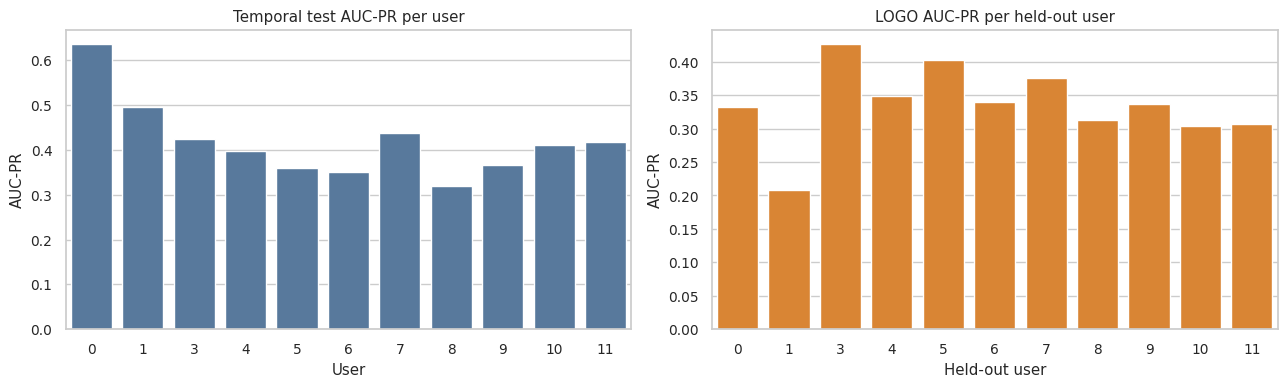

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=temporal_user_results, x="USER", y="auc_pr", ax=axes[0], color="#4C78A8")
axes[0].set_title("Temporal test AUC-PR per user")
axes[0].set_xlabel("User")
axes[0].set_ylabel("AUC-PR")

if not logo_selected.empty:
  sns.barplot(data=logo_selected.sort_values("test_user"), x="test_user", y="auc_pr", ax=axes[1], color="#F58518")
  axes[1].set_title("LOGO AUC-PR per held-out user")
  axes[1].set_xlabel("Held-out user")
  axes[1].set_ylabel("AUC-PR")
else:
  axes[1].axis("off")
plt.tight_layout()
plt.show()


### Interpretacja stabilności per użytkownik

W temporal test model działa najlepiej dla User 0, AUC-PR 0.6357, oraz dobrze dla User 1, AUC-PR 0.4953. Najsłabszy wynik temporalny ma User 8, AUC-PR 0.3189. To pokazuje, że przy znanych użytkownikach model potrafi wykorzystać część indywidualnych wzorców.

LOGO jest dużo surowsze. Dla User 1, który temporalnie wygląda dobrze, wynik LOGO spada do AUC-PR około 0.2080 i ROC-AUC około 0.4992. To jest najważniejszy sygnał ograniczenia: model może dobrze przewidywać przyszłość użytkowników podobnych do treningu, ale nie zawsze przenosi się na osobę niewidzianą wcześniej.


## Sekcja 6: Zapis artefaktów i decyzja

Zapisujemy tabele interpretacyjne jako lokalne artefakty. Kolejny notebook powinien sprawdzić, czy wnioski utrzymują się przy zmianie definicji targetu i horyzontu predykcji.


In [11]:
interpretation_summary: dict[str, object] = {
  "target": TARGET_COL,
  "selected_model": model_decision["selected_model"],
  "selected_feature_set": model_decision["selected_feature_set"],
  "test_auc_pr": float(model_recheck.loc[0, "auc_pr"]),
  "test_roc_auc": float(model_recheck.loc[0, "roc_auc"]),
  "test_brier": float(model_recheck.loc[0, "brier"]),
  "top_mdi_features": mdi_importance.head(5).to_dict(orient="records"),
  "top_permutation_features": permutation_importance_df.head(5).to_dict(orient="records"),
  "top_decile_positive_pct": float(risk_deciles.loc[risk_deciles["risk_decile"] == 10, "positive_pct"].iloc[0]),
  "top_decile_capture_pct": float(top_decile_capture_pct),
  "main_interpretation": "Risk is driven by application context, typing rhythm, idle ratio, input intensity, and correction ratio.",
  "main_limitation": "Temporal user-level results are stronger than LOGO results, so user transfer remains limited.",
}

importance_comparison.to_csv(FEATURE_IMPORTANCE_PATH, index=False)
permutation_importance_df.to_csv(PERMUTATION_IMPORTANCE_PATH, index=False)
risk_deciles.to_csv(RISK_DECILES_PATH, index=False)
feature_profiles.to_csv(FEATURE_PROFILES_PATH, index=False)
SUMMARY_PATH.write_text(json.dumps(interpretation_summary, indent=2), encoding="utf-8")

print(f"Saved feature importance: {FEATURE_IMPORTANCE_PATH}")
print(f"Saved permutation importance: {PERMUTATION_IMPORTANCE_PATH}")
print(f"Saved risk deciles: {RISK_DECILES_PATH}")
print(f"Saved feature profiles: {FEATURE_PROFILES_PATH}")
print(f"Saved interpretation summary: {SUMMARY_PATH}")


Saved feature importance: /home/sefni/git/bwci-thesis/outputs/model_interpretation_feature_importance_drop_10_v0_1.csv
Saved permutation importance: /home/sefni/git/bwci-thesis/outputs/model_interpretation_permutation_drop_10_v0_1.csv
Saved risk deciles: /home/sefni/git/bwci-thesis/outputs/model_interpretation_risk_deciles_drop_10_v0_1.csv
Saved feature profiles: /home/sefni/git/bwci-thesis/outputs/model_interpretation_feature_profiles_drop_10_v0_1.csv
Saved interpretation summary: /home/sefni/git/bwci-thesis/outputs/model_interpretation_summary_drop_10_v0_1.json


## Krótkie sprawozdanie z etapu 10

Etap 10 pokazuje, że model `behavior_random_forest` nie jest czarną skrzynką opartą na pojedynczym sygnale. Najważniejsze grupy cech to kontekst aplikacji, rytm pisania, idle, intensywność wejścia oraz korekty.

Najmocniejszy praktyczny wynik to ranking ryzyka: najwyższy decyl predykcji ma 47.83% zdarzeń `drop_10` i przechwytuje 30.03% wszystkich zdarzeń pozytywnych w teście. Najważniejsze ograniczenie pozostaje takie samo jak po 09: interpretacja jest wiarygodniejsza dla predykcji temporalnej niż dla transferu na całkowicie nowego użytkownika.
